# 15. Fechamento da análise de Granger: grupos e tipologias

**Pergunta:** o histórico de desastres acrescenta informação à dinâmica da inadimplência PF?

Cobertura completa: total nacional, quatro grupos, 16 tipologias × pré-pandemia (jan/2013–jan/2020) e total (jan/2013–dez/2024). Os recortes se sobrepõem. Extensão informada, sem confirmação independente ou identificação causal.

O protocolo foi publicado antes destes novos testes. Principal: defasagens fixas, diferença sazonal sobre primeira diferença, histórico próprio1/2/3/12 e exposição1/2/3. Isso remove a seleção BIC da especificação principal; não elimina limitações estatísticas.

In [1]:
from pathlib import Path
import sys, warnings
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from granger_fechamento import *
from IPython.display import display, Markdown
pd.set_option('display.max_columns',30)
raw,keys=inputs()
display(Markdown('Fonte: CSV nacional agregado cujo hash confere com checkpoint11. Não há nova auditoria de bases brutas.'))
display(pd.DataFrame([{'Período':p,'Meses originais':len(raw.loc[a:b]),'Exposições':len(keys)} for p,(a,b) in PERIODS.items()]))

Fonte: CSV nacional agregado cujo hash confere com checkpoint11. Não há nova auditoria de bases brutas.

,Período,Meses originais,Exposições
0,Pré-pandemia (até jan/2020),85,21
1,Total (2013–2024),144,21


## 1. Séries, estacionariedade e cobertura

ADF e KPSS têm hipóteses nulas diferentes; concordância é triagem, não prova. Nenhuma série é diferenciada repetidamente até passar. Meses esparsos podem limitar os testes. Não excluir diagnósticos ruins antes de BH.

Principal42 e sensibilidades126 são famílias fixas. Também se mostra correção global168. P-valores das sensibilidades BIC permanecem pós-seleção.

In [2]:
resultados=run()
display(pd.read_csv(OUT/'cobertura.csv'))
display(pd.read_csv(OUT/'resumo.csv'))
st=pd.read_csv(OUT/'estacionariedade.csv')
display(st.groupby(['Período','Especificação','Série','Status']).size().rename('Cenários').reset_index())

Concluído Pré-pandemia (até jan/2020)
Concluído Total (2013–2024)


,Período,Exposição,Nível,Unidade geográfica,Direção,Meses originais,Meses positivos,Protocolos,Ausentes,Variância original,Elegível exposição,Motivo exposição
0,Pré-pandemia (até jan/2020),Total nacional,Referência,Brasil,Desastres → inadimplência,85,85,18426,0,15717.770868,True,NaN
1,Pré-pandemia (até jan/2020),Grupo | Climatológico,Grupo,Brasil,Desastres → inadimplência,85,85,9721,0,8358.258263,True,NaN
2,Pré-pandemia (até jan/2020),Grupo | Hidrológico,Grupo,Brasil,Desastres → inadimplência,85,85,6344,0,4004.663025,True,NaN
3,Pré-pandemia (até jan/2020),Grupo | Meteorológico,Grupo,Brasil,Desastres → inadimplência,85,85,1584,0,469.091597,True,NaN
4,Pré-pandemia (até jan/2020),Grupo | Outros,Grupo,Brasil,Desastres → inadimplência,85,82,777,0,181.289356,True,NaN
5,Pré-pandemia (até jan/2020),Tipologia | Alagamentos,Tipologia,Brasil,Desastres → inadimplência,85,81,730,0,50.054622,True,NaN
6,Pré-pandemia (até jan/2020),Tipologia | Chuvas Intensas,Tipologia,Brasil,Desastres → inadimplência,85,83,2185,0,836.305322,True,NaN
7,Pré-pandemia (até jan/2020),Tipologia | Doenças infecciosas,Tipologia,Brasil,Desastres → inadimplência,85,39,235,0,139.634454,True,NaN
8,Pré-pandemia (até jan/2020),Tipologia | Enxurradas,Tipologia,Brasil,Desastres → inadimplência,85,81,1887,0,567.423810,True,NaN
9,Pré-pandemia (até jan/2020),Tipologia | Erosão,Tipologia,Brasil,Desastres → inadimplência,85,76,285,0,5.754902,True,NaN


,Família,Período,Planejados,Estimáveis,Nominais,BH,BY,Holm,Triagem_básica,Triagem_ampliada
0,PRINCIPAL,Pré-pandemia (até jan/2020),21,19,8,5,1,1,0,0
1,SENSIBILIDADES,Pré-pandemia (até jan/2020),63,57,20,11,5,5,0,0
2,PRINCIPAL,Total (2013–2024),21,21,9,5,1,1,6,4
3,SENSIBILIDADES,Total (2013–2024),63,63,22,9,1,1,37,20


,Período,Especificação,Série,Status,Cenários
0,Pré-pandemia (até jan/2020),Principal sazonal fixa,D,Compatível com estacionariedade,21
1,Pré-pandemia (até jan/2020),Principal sazonal fixa,I,Inconclusiva,21
2,Pré-pandemia (até jan/2020),Relativa sazonal fixa,D,Compatível com estacionariedade,21
3,Pré-pandemia (até jan/2020),Relativa sazonal fixa,I,Inconclusiva,21
4,Pré-pandemia (até jan/2020),Sazonal BIC,D,Compatível com estacionariedade,21
5,Pré-pandemia (até jan/2020),Sazonal BIC,I,Inconclusiva,21
6,Pré-pandemia (até jan/2020),Simples fixa com dummies,D,Compatível com estacionariedade,21
7,Pré-pandemia (até jan/2020),Simples fixa com dummies,I,Inconclusiva,21
8,Total (2013–2024),Principal sazonal fixa,D,Compatível com estacionariedade,20
9,Total (2013–2024),Principal sazonal fixa,D,Inconclusiva,1


/workspace/scratch/aee47d7b6859/tcc/src/segunda_etapa.py:100: FutureWarning: acorr_breusch_godfrey currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r={'BG1 p':acorr_breusch_godfrey(model,nlags=1)[1],'BG12 p':acorr_breusch_godfrey(model,nlags=12)[1],'BP p':het_breuschpagan(model.resid,model.model.exog)[1],'ARCH3 p':het_arch(model.resid,nlags=3)[1],'CUSUM p':breaks_cusumolsresid(model.resid,ddof=len(model.params))[1],'RESET p':linear_reset(model,power=2,test_type='fitted',use_f=True,cov_type='HC3').pvalue,'ACF12':acf(model.resid,nlags=12,fft=False)[12],'Raiz própria':roots(model)}
/root/.local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tup

### Descritivas, sazonalidade e séries em nível

Os zeros são contagens mensais reconciliadas na entrada agregada validada; não implicam ausência de danos humanos ou monetários. A classificação administrativa original pode associar uma mesma tipologia a mais de um grupo. Os códigos numéricos do Atlas não foram preservados neste agregado e não podem ser reconstituídos sem a base bruta. Os nomes originais e a tabela de classificação anterior permanecem preservados.

As descritivas abaixo cobrem **todos os cenários** e os ADF/KPSS em nível complementam os testes das transformações. As curvas não são testes de causalidade. A diferenciação sazonal remove mudanças anuais da variação mensal; seu objeto difere da taxa em nível.

,Período,Exposição,Nível,Unidade geográfica,Direção,Série,ADF estatística,ADF p,ADF lag,ADF n,KPSS estatística,KPSS p,KPSS lag,KPSS limite,Estacionária,Avisos,Status,n transformado,Variância
0,Pré-pandemia (até jan/2020),Total nacional,Referência,Brasil,Desastres → inadimplência,I,-2.468750,1.232640e-01,6,78,0.901036,0.010000,5,<=0.01,False,limite tabular; transição de API registrada,Indicação de não estacionariedade,85,0.149626
1,Pré-pandemia (até jan/2020),Total nacional,Referência,Brasil,Desastres → inadimplência,D,-8.441592,1.757233e-13,0,84,0.047868,0.100000,1,>=0.10,True,limite tabular; transição de API registrada,Compatível com estacionariedade,85,15717.770868
2,Pré-pandemia (até jan/2020),Grupo | Climatológico,Grupo,Brasil,Desastres → inadimplência,I,-2.468750,1.232640e-01,6,78,0.901036,0.010000,5,<=0.01,False,limite tabular; transição de API registrada,Indicação de não estacionariedade,85,0.149626
3,Pré-pandemia (até jan/2020),Grupo | Climatológico,Grupo,Brasil,Desastres → inadimplência,D,-9.251897,1.484533e-15,0,84,0.106447,0.100000,0,>=0.10,True,limite tabular; transição de API registrada,Compatível com estacionariedade,85,8358.258263
4,Pré-pandemia (até jan/2020),Grupo | Hidrológico,Grupo,Brasil,Desastres → inadimplência,I,-2.468750,1.232640e-01,6,78,0.901036,0.010000,5,<=0.01,False,limite tabular; transição de API registrada,Indicação de não estacionariedade,85,0.149626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,Total (2013–2024),Tipologia | Rompimento/Colapso de barragens,Tipologia,Brasil,Desastres → inadimplência,D,-10.923226,1.025447e-19,0,143,0.500850,0.041475,3,interpolado,False,transição de API registrada,Inconclusiva,144,0.601204
80,Total (2013–2024),Tipologia | Tornado,Tipologia,Brasil,Desastres → inadimplência,I,-2.361729,1.528306e-01,7,136,0.696208,0.013890,8,interpolado,False,transição de API registrada,Indicação de não estacionariedade,144,0.209374
81,Total (2013–2024),Tipologia | Tornado,Tipologia,Brasil,Desastres → inadimplência,D,-11.935461,4.673896e-22,0,143,0.057604,0.100000,5,>=0.10,True,limite tabular; transição de API registrada,Compatível com estacionariedade,144,1.020979
82,Total (2013–2024),Tipologia | Vendavais e Ciclones,Tipologia,Brasil,Desastres → inadimplência,I,-2.361729,1.528306e-01,7,136,0.696208,0.013890,8,interpolado,False,transição de API registrada,Indicação de não estacionariedade,144,0.209374


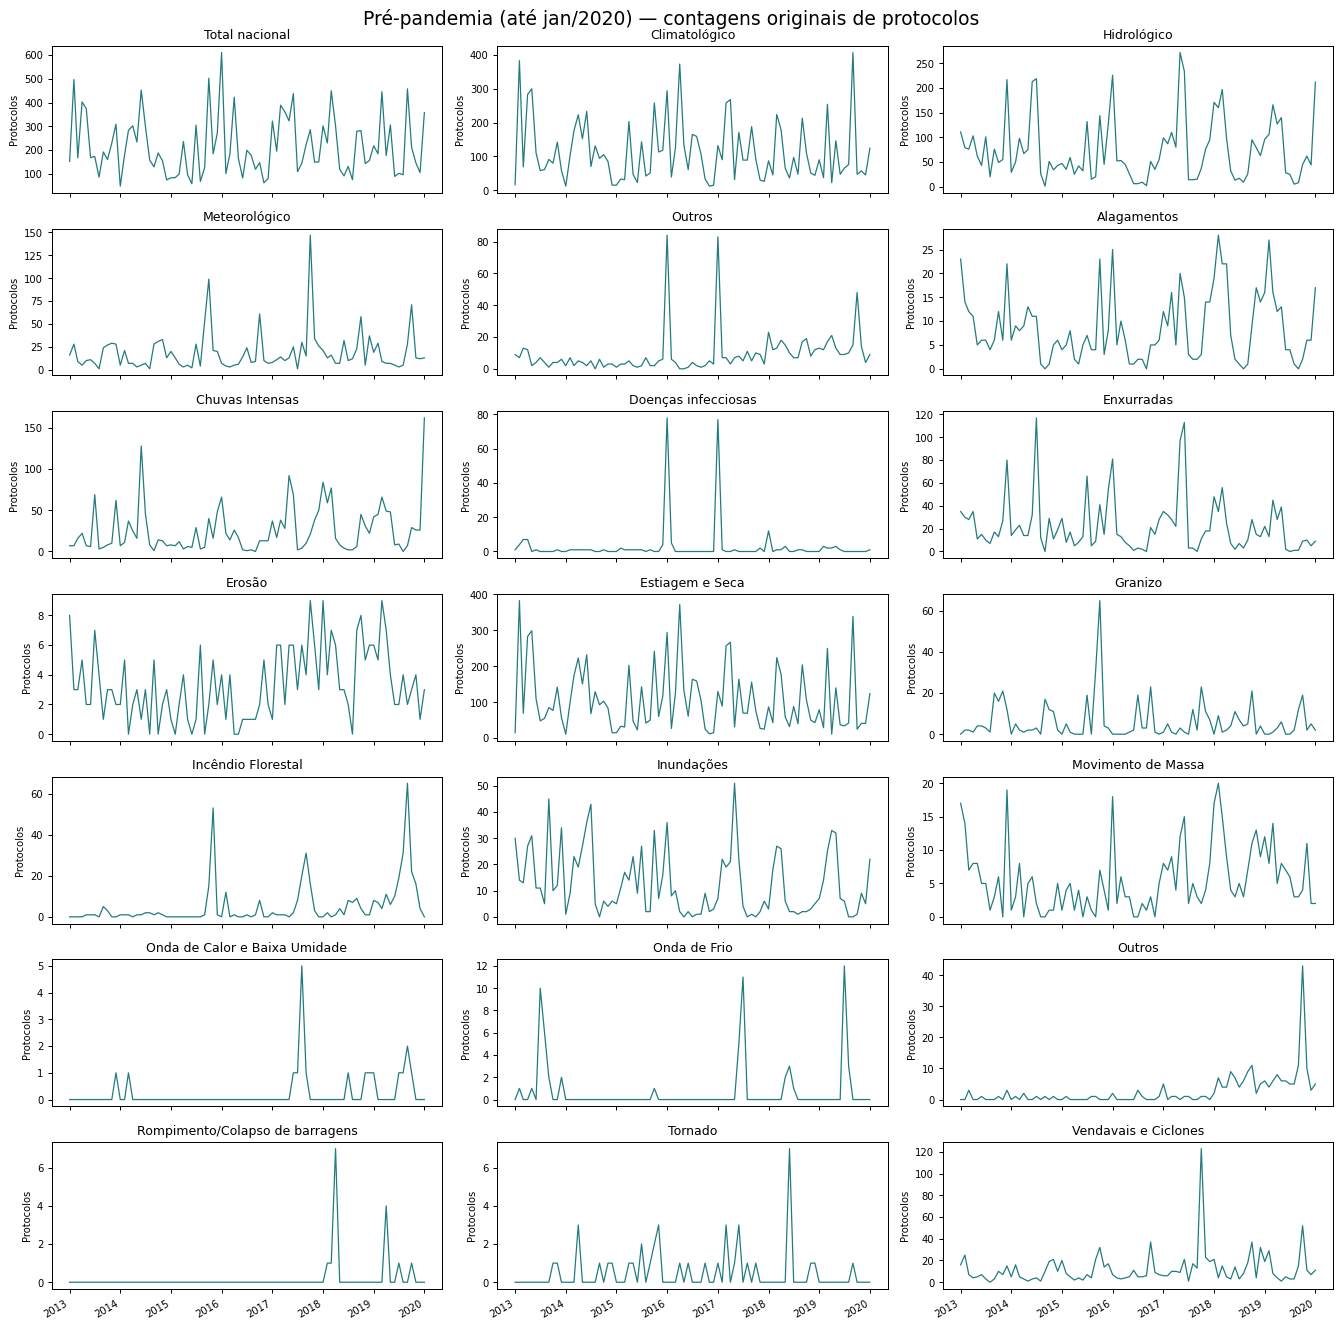

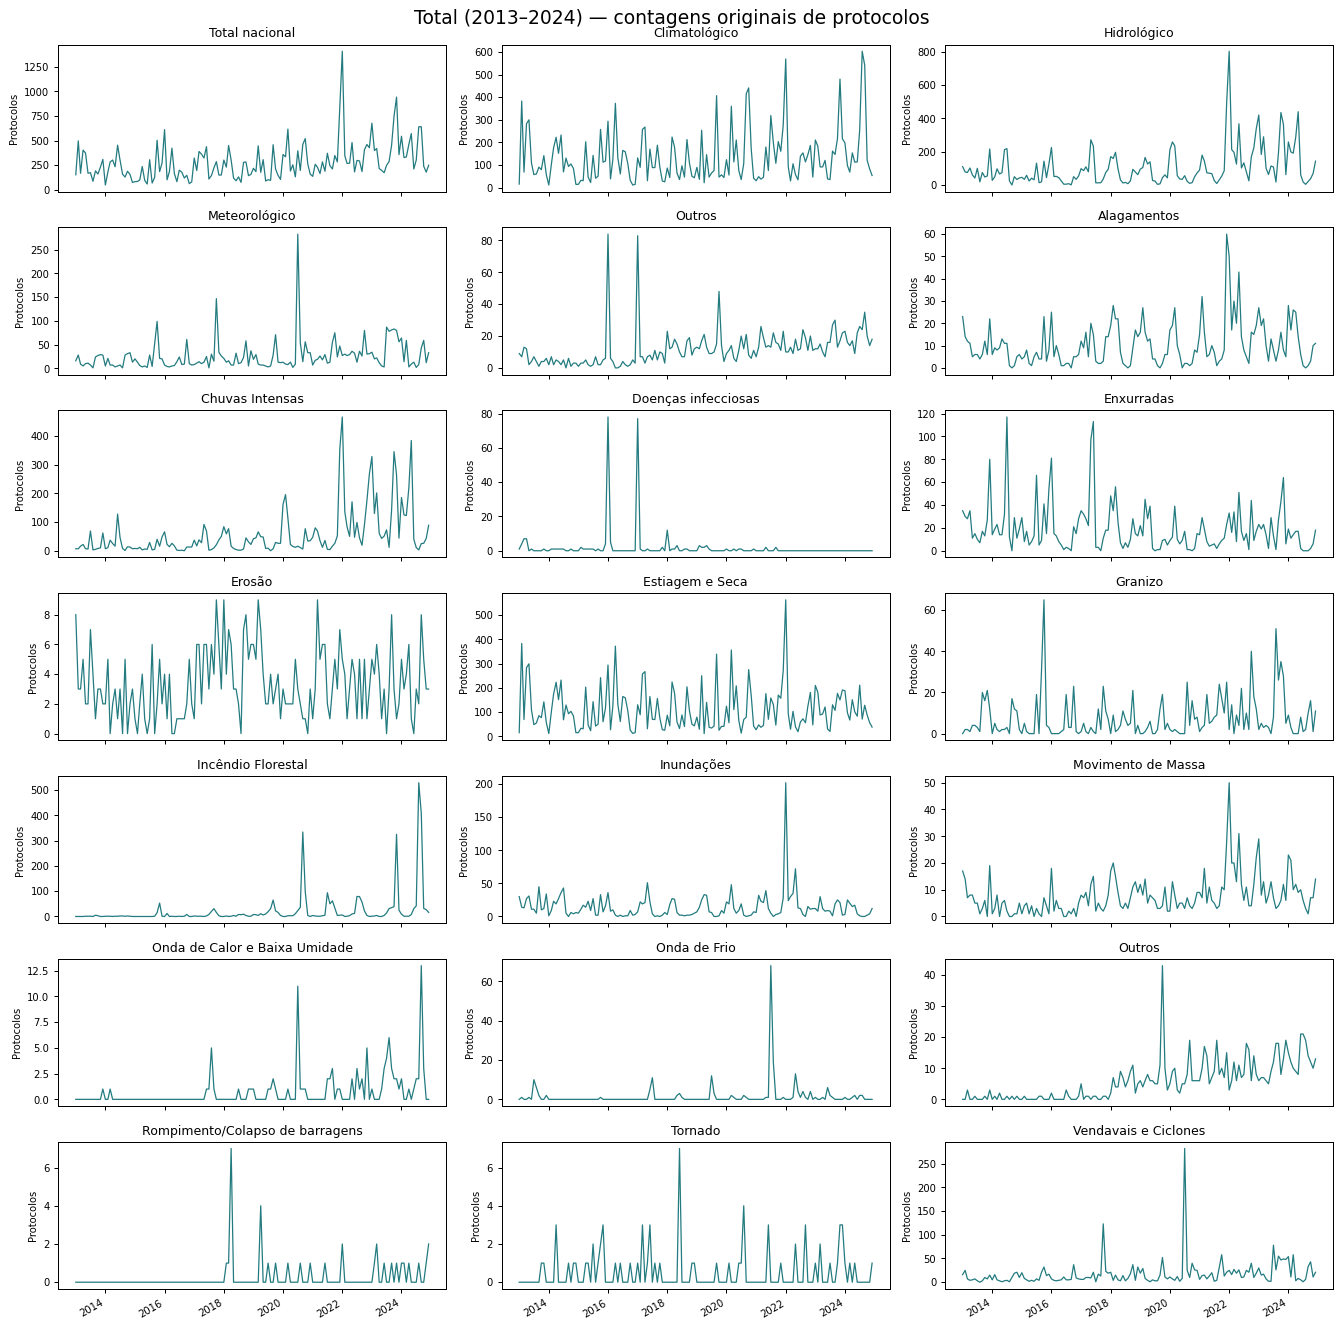

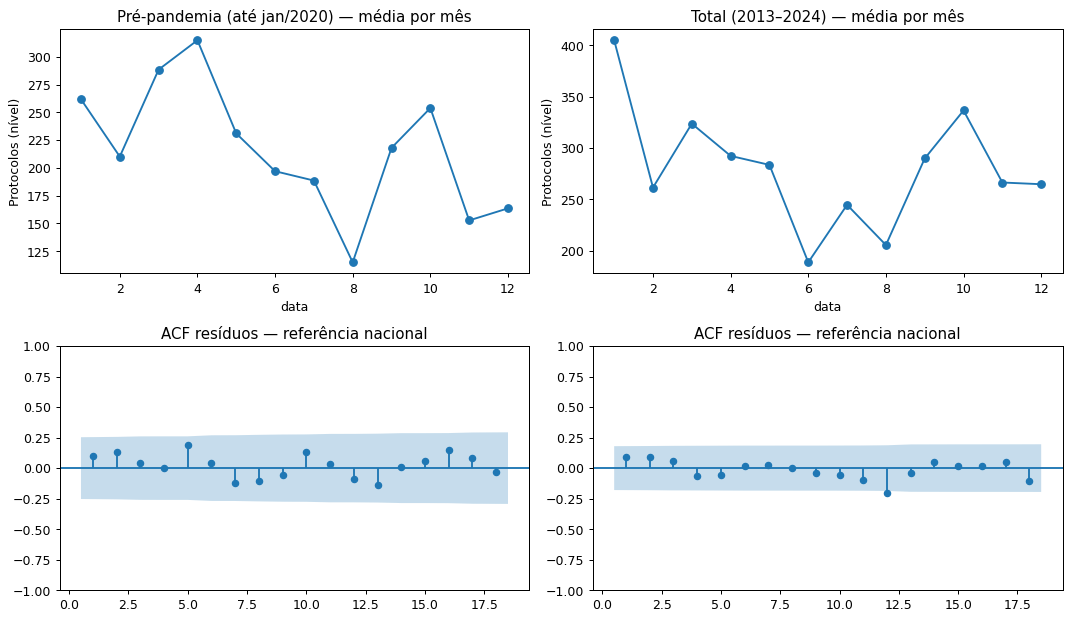

In [3]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
raw,keys=inputs()
display(pd.read_csv(OUT/'estacionariedade_nivel.csv'))
for per,(ini,fim) in PERIODS.items():
    s=raw.loc[ini:fim]
    fig,axes=plt.subplots(7,3,figsize=(15,15),sharex=True)
    for ax,key in zip(axes.flat,keys):
        ax.plot(s.index,s[key],color='#237b80',linewidth=1)
        ax.set_title(key.replace('Tipologia | ','').replace('Grupo | ',''),fontsize=10)
        ax.tick_params(labelsize=8);ax.set_ylabel('Protocolos',fontsize=8)
    fig.suptitle(per+' — contagens originais de protocolos',fontsize=15)
    fig.autofmt_xdate();plt.tight_layout();plt.show();plt.close(fig)
fig,axes=plt.subplots(2,2,figsize=(12,7))
for j,(per,(ini,fim)) in enumerate(PERIODS.items()):
    s=raw.loc[ini:fim]
    s.groupby(s.index.month)['Total nacional'].mean().plot(ax=axes[0,j],marker='o')
    axes[0,j].set_title(per+' — média por mês');axes[0,j].set_ylabel('Protocolos (nível)')
    g=pd.read_csv(OUT/'residuos_referencia.csv');v=g[(g.Período==per)&(g.Exposição=='Total nacional')]['Resíduo']
    plot_acf(v,lags=18,ax=axes[1,j],title='ACF resíduos — referência nacional',zero=False)
plt.tight_layout();plt.show();plt.close(fig)


## 2. Matriz de Granger: todas as categorias nos dois períodos

Wald-F conjunto testa os lags1–3, não o sinal de cada lag. Coeficientes/IC são associações condicionais nas unidades transformadas. A soma não é efeito de um protocolo adicional nem resposta causal acumulada.

Diagnósticos da equação não são diagnósticos de VAR. Os cenários não estimados permanecem com p original ausente. Prefêrencia q0 é parcimônia, separada de adequação.

### Pré-pandemia (até jan/2020)

,Exposição,n efetivo,p,p BH,p BY,p Holm,Soma coeficientes,IC baixo,IC alto,Triagem básica,Triagem ampliada,Motivos
0,Total nacional,60.0,0.066807,0.140295,0.607021,1.000000,0.044026,0.007196,0.080856,False,False,Estacionariedade I: Inconclusiva
4,Grupo | Climatológico,60.0,0.006303,0.026471,0.114532,0.207985,0.036612,-0.006551,0.079775,False,False,Estacionariedade I: Inconclusiva
8,Grupo | Hidrológico,60.0,0.735520,0.858106,1.000000,1.000000,0.016138,-0.023765,0.056041,False,False,Estacionariedade I: Inconclusiva
12,Grupo | Meteorológico,60.0,0.489317,0.604451,1.000000,1.000000,0.015236,-0.022421,0.052892,False,False,Estacionariedade I: Inconclusiva
16,Grupo | Outros,60.0,0.000020,0.000840,0.003636,0.000840,0.001162,-0.036334,0.038657,False,False,Estacionariedade I: Inconclusiva; Influência m...
20,Tipologia | Alagamentos,60.0,0.002460,0.020666,0.089417,0.093490,0.057912,-0.005105,0.120929,False,False,Estacionariedade I: Inconclusiva
24,Tipologia | Chuvas Intensas,60.0,0.764564,0.867883,1.000000,1.000000,0.005073,-0.028877,0.039022,False,False,Estacionariedade I: Inconclusiva
28,Tipologia | Doenças infecciosas,60.0,0.005913,0.026471,0.114532,0.201031,-0.016332,-0.052025,0.019360,False,False,Estacionariedade I: Inconclusiva
32,Tipologia | Enxurradas,60.0,0.385278,0.505678,1.000000,1.000000,0.004983,-0.024303,0.034270,False,False,Estacionariedade I: Inconclusiva
36,Tipologia | Erosão,60.0,0.166097,0.290669,1.000000,1.000000,0.033269,-0.027324,0.093862,False,False,Estacionariedade I: Inconclusiva


### Total (2013–2024)

,Exposição,n efetivo,p,p BH,p BY,p Holm,Soma coeficientes,IC baixo,IC alto,Triagem básica,Triagem ampliada,Motivos
84,Total nacional,119.0,0.003459,0.020761,0.089827,0.127987,0.042148,0.016722,0.067575,False,False,Autocorrelação curta; Mudança após março2020
88,Grupo | Climatológico,119.0,0.054412,0.126961,0.549328,1.000000,0.021850,-0.000401,0.044102,False,False,Autocorrelação curta; Mudança após março2020
92,Grupo | Hidrológico,119.0,0.030305,0.081132,0.351039,0.848534,0.032562,0.008223,0.056900,True,True,Sem indicação nos critérios examinados
96,Grupo | Meteorológico,119.0,0.303768,0.439941,1.000000,1.000000,-0.016354,-0.046636,0.013929,False,False,Autocorrelação curta
100,Grupo | Outros,119.0,0.248269,0.386197,1.000000,1.000000,0.029841,-0.005088,0.064769,False,False,Autocorrelação curta; Mudança após março2020
104,Tipologia | Alagamentos,119.0,0.003954,0.020761,0.089827,0.138406,0.039001,0.000716,0.077287,False,False,Estacionariedade D: Inconclusiva; Mudança após...
108,Tipologia | Chuvas Intensas,119.0,0.044888,0.110899,0.479831,1.000000,0.033272,0.006893,0.059651,True,True,Sem indicação nos critérios examinados
112,Tipologia | Doenças infecciosas,119.0,0.103853,0.198265,0.857840,1.000000,-0.021193,-0.057399,0.015014,True,False,Mudança após março2020
116,Tipologia | Enxurradas,119.0,0.827932,0.915082,1.000000,1.000000,-0.002120,-0.023303,0.019062,False,False,Autocorrelação curta; Mudança após março2020
120,Tipologia | Erosão,119.0,0.684213,0.821056,1.000000,1.000000,0.017361,-0.023338,0.058060,False,False,Autocorrelação curta; Mudança após março2020


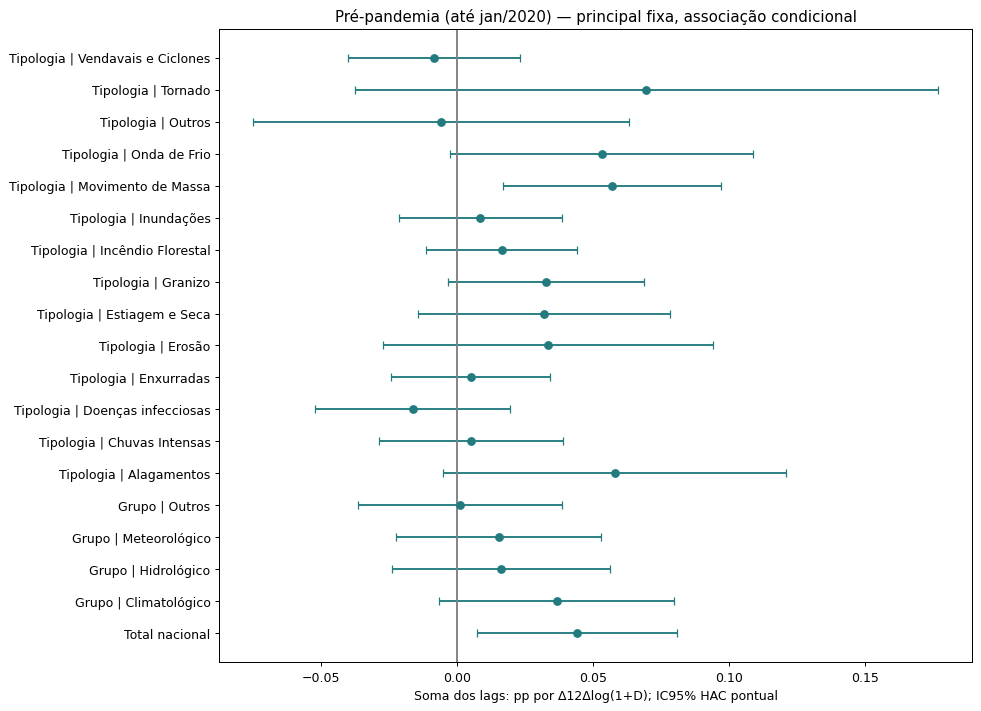

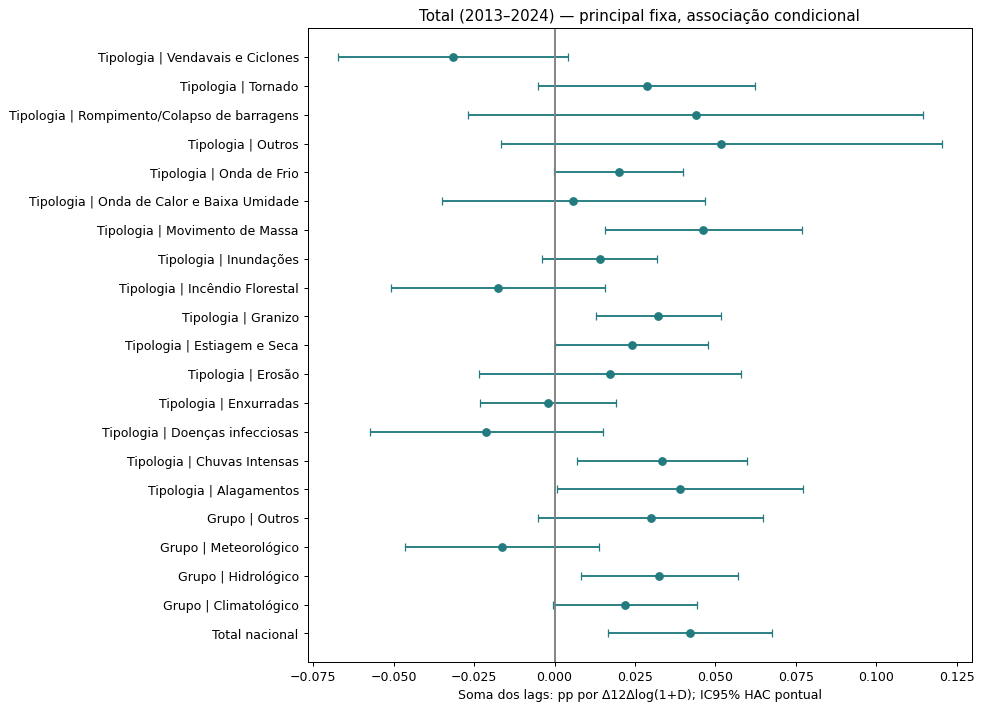

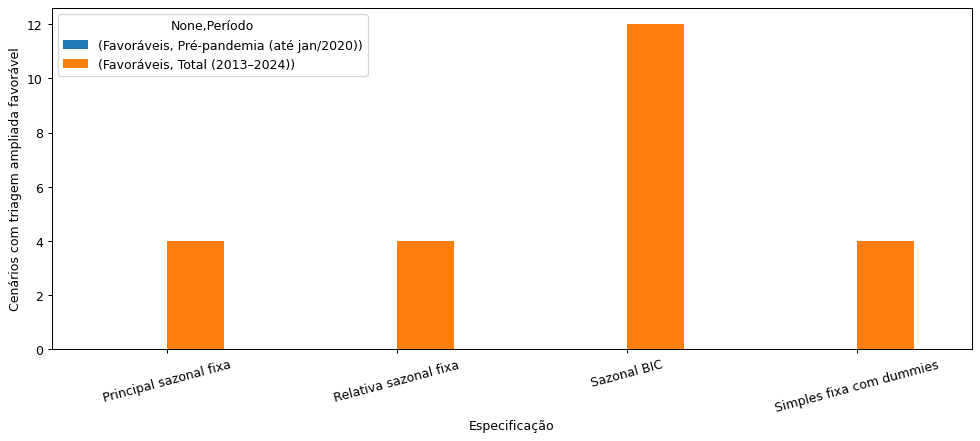

In [4]:
principal=resultados[resultados.Família=='PRINCIPAL']
for per in PERIODS:
    display(Markdown('### '+per))
    display(principal[principal.Período==per][['Exposição','n efetivo','p','p BH','p BY','p Holm','Soma coeficientes','IC baixo','IC alto','Triagem básica','Triagem ampliada','Motivos']])
figures(resultados)

## 3. Estabilidade e diagnósticos individuais

A triagem básica reproduz os critérios diagnósticos anteriores, sem q0. A ampliada acrescenta, no total, o teste de indicador/interações pós-março2020. O teste geral pode detectar mudança na inadimplência, na associação dos desastres ou no intercepto; não atribui causalidade à pandemia. O teste específico dos termos de exposição é registrado separadamente. Pré: março2020 fora da janela, não aplicável.

CUSUM e teste de mudança avaliam aspectos diferentes; discordância não é apagada. BH84 de estabilidade é apresentado, mas uma rejeição nominal permanece limitação, segundo protocolo.

In [5]:
display(principal[principal.p.notna()][['Período','Exposição','BG1 p','BG12 p','BP p','ARCH3 p','RESET p','CUSUM p','Raiz própria','Δ soma influência','Estabilidade p','Estabilidade BH84','Interação exposição p','Estabilidade status']])
display(resultados[resultados['p BH']<.05][['Família','Período','Exposição','Especificação','p','p BH','p BY','p Holm','p BH global168','BH p clássico','BH p HC3','Triagem ampliada','Motivos']])
display(principal[principal.p.notna()][['Período','Exposição','BG1 LM','BG1 F','BG12 LM','BG12 F','BP LM','BP F','ARCH3 LM','ARCH3 F','CUSUM estatística','RESET F','Estabilidade F','Interação exposição F']])

,Período,Exposição,BG1 p,BG12 p,BP p,ARCH3 p,RESET p,CUSUM p,Raiz própria,Δ soma influência,Estabilidade p,Estabilidade BH84,Interação exposição p,Estabilidade status
0,Pré-pandemia (até jan/2020),Total nacional,0.129862,0.282048,0.884964,0.304474,0.385895,0.201130,0.968185,-0.003621,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
4,Pré-pandemia (até jan/2020),Grupo | Climatológico,0.179136,0.128931,0.642902,0.149194,0.667967,0.180468,0.965346,-0.000710,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
8,Pré-pandemia (até jan/2020),Grupo | Hidrológico,0.712077,0.396903,0.626097,0.850436,0.649039,0.306847,0.961781,-0.003633,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
12,Pré-pandemia (até jan/2020),Grupo | Meteorológico,0.246694,0.234643,0.939071,0.598035,0.480700,0.232704,0.967117,-0.006996,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
16,Pré-pandemia (até jan/2020),Grupo | Outros,0.187836,0.189448,0.326192,0.807608,0.984650,0.208124,0.968023,-0.019298,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
20,Pré-pandemia (até jan/2020),Tipologia | Alagamentos,0.672771,0.643170,0.456380,0.732030,0.960294,0.623488,0.947726,0.012190,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
24,Pré-pandemia (até jan/2020),Tipologia | Chuvas Intensas,0.590347,0.445604,0.431792,0.815670,0.707100,0.276529,0.959523,-0.004630,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
28,Pré-pandemia (até jan/2020),Tipologia | Doenças infecciosas,0.506932,0.212483,0.816154,0.927026,0.651975,0.254796,0.961799,0.002517,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
32,Pré-pandemia (até jan/2020),Tipologia | Enxurradas,0.613264,0.286780,0.964018,0.823643,0.758130,0.289382,0.957823,-0.003676,NaN,NaN,NaN,Não aplicável: março2020 fora do pré
36,Pré-pandemia (até jan/2020),Tipologia | Erosão,0.215498,0.203017,0.789443,0.872817,0.963247,0.260796,0.965380,-0.022020,NaN,NaN,NaN,Não aplicável: março2020 fora do pré


,Família,Período,Exposição,Especificação,p,p BH,p BY,p Holm,p BH global168,BH p clássico,BH p HC3,Triagem ampliada,Motivos
4,PRINCIPAL,Pré-pandemia (até jan/2020),Grupo | Climatológico,Principal sazonal fixa,6.302569e-03,0.026471,0.114532,0.207985,0.036511,0.530553,0.585947,False,Estacionariedade I: Inconclusiva
7,SENSIBILIDADES,Pré-pandemia (até jan/2020),Grupo | Climatológico,Sazonal BIC,1.412943e-03,0.017803,0.096448,0.165314,0.019781,0.511578,0.469397,False,Estacionariedade I: Inconclusiva
16,PRINCIPAL,Pré-pandemia (até jan/2020),Grupo | Outros,Principal sazonal fixa,2.000804e-05,0.000840,0.003636,0.000840,0.001681,0.675650,0.585947,False,Estacionariedade I: Inconclusiva; Influência m...
17,SENSIBILIDADES,Pré-pandemia (até jan/2020),Grupo | Outros,Simples fixa com dummies,3.902138e-07,0.000049,0.000266,0.000049,0.000066,0.511578,0.518306,False,Estacionariedade I: Inconclusiva
18,SENSIBILIDADES,Pré-pandemia (até jan/2020),Grupo | Outros,Relativa sazonal fixa,3.330039e-05,0.002098,0.011365,0.004163,0.001865,0.701076,0.682560,False,Estacionariedade I: Inconclusiva; Influência m...
20,PRINCIPAL,Pré-pandemia (até jan/2020),Tipologia | Alagamentos,Principal sazonal fixa,2.460264e-03,0.020666,0.089417,0.093490,0.024313,0.530553,0.429249,False,Estacionariedade I: Inconclusiva
22,SENSIBILIDADES,Pré-pandemia (até jan/2020),Tipologia | Alagamentos,Relativa sazonal fixa,3.836630e-03,0.032228,0.174592,0.429703,0.028885,0.553520,0.469397,False,Estacionariedade I: Inconclusiva
23,SENSIBILIDADES,Pré-pandemia (até jan/2020),Tipologia | Alagamentos,Sazonal BIC,7.106523e-04,0.011193,0.060636,0.084568,0.011939,0.511578,0.469397,False,Estacionariedade I: Inconclusiva; Autocorrelaç...
28,PRINCIPAL,Pré-pandemia (até jan/2020),Tipologia | Doenças infecciosas,Principal sazonal fixa,5.912670e-03,0.026471,0.114532,0.201031,0.036511,0.797058,0.705388,False,Estacionariedade I: Inconclusiva
29,SENSIBILIDADES,Pré-pandemia (até jan/2020),Tipologia | Doenças infecciosas,Simples fixa com dummies,6.776105e-03,0.042689,0.231268,0.725043,0.037946,0.888809,1.000000,False,Estacionariedade I: Inconclusiva


,Período,Exposição,BG1 LM,BG1 F,BG12 LM,BG12 F,BP LM,BP F,ARCH3 LM,ARCH3 F,CUSUM estatística,RESET F,Estabilidade F,Interação exposição F
0,Pré-pandemia (até jan/2020),Total nacional,2.294151,2.027553,14.298597,1.042900,3.000418,0.391035,3.628502,1.201082,1.071431,0.764914,NaN,NaN
4,Pré-pandemia (até jan/2020),Grupo | Climatológico,1.804777,1.581635,17.583606,1.381825,5.139844,0.695982,5.329591,1.822244,1.096497,0.186140,NaN,NaN
8,Pré-pandemia (até jan/2020),Grupo | Hidrológico,0.136211,0.116043,12.624643,0.888271,5.277846,0.716471,0.795946,0.250190,0.967186,0.209583,NaN,NaN
12,Pré-pandemia (até jan/2020),Grupo | Meteorológico,1.341932,1.166737,15.125538,1.123545,2.333980,0.300665,1.878351,0.602017,1.036714,0.504650,NaN,NaN
16,Pré-pandemia (até jan/2020),Grupo | Outros,1.734513,1.518226,16.039179,1.216172,8.073106,1.154925,0.973732,0.307045,1.063399,0.000374,NaN,NaN
20,Pré-pandemia (até jan/2020),Tipologia | Alagamentos,0.178378,0.152074,9.689609,0.641989,6.740591,0.940171,1.287807,0.408371,0.752186,0.002503,NaN,NaN
24,Pré-pandemia (até jan/2020),Tipologia | Chuvas Intensas,0.289802,0.247527,12.000937,0.833415,6.972087,0.976705,0.940395,0.296357,0.993961,0.142781,NaN,NaN
28,Pré-pandemia (até jan/2020),Tipologia | Doenças infecciosas,0.440396,0.377104,15.554904,1.166601,3.676849,0.484947,0.462609,0.144555,1.014484,0.205837,NaN,NaN
32,Pré-pandemia (até jan/2020),Tipologia | Enxurradas,0.255449,0.218060,14.221631,1.035542,1.922247,0.245869,0.907394,0.285789,0.982368,0.095849,NaN,NaN
36,Pré-pandemia (até jan/2020),Tipologia | Erosão,1.534103,1.338203,15.748742,1.186312,3.915625,0.518638,0.701646,0.220180,1.008695,0.002144,NaN,NaN


## 4. Onda de Frio e comparação histórica

Onda de Frio foi sinal exploratório na etapa14. Não tratar menor família ou outra especificação como confirmação independente. Os ajustes históricos200/32 e235 anteriores permanecem intactos. Os resultados novos têm famílias42/126/168; diferenças de ajustes podem refletir a família, não aumento da evidência.

In [6]:
display(resultados[resultados.Exposição=='Tipologia | Onda de Frio'][['Período','Especificação','p','p BH','p BY','p Holm','q0 preferido','Triagem básica','Triagem ampliada','Motivos']])
old=pd.read_csv(ROOT/'outputs/tables/adequacao/nacional.csv')
display(old[(old.Exposição=='Tipologia | Onda de Frio') & (old.Transformação=='Diferença sazonal')][['Período','p','p BH','p BY','p Holm','Diagnóstico favorável','q0 preferido']])

,Período,Especificação,p,p BH,p BY,p Holm,q0 preferido,Triagem básica,Triagem ampliada,Motivos
64,Pré-pandemia (até jan/2020),Principal sazonal fixa,0.189996,0.319194,1.000000,1.000000,None,False,False,Estacionariedade I: Inconclusiva
65,Pré-pandemia (até jan/2020),Simples fixa com dummies,0.127839,0.282592,1.000000,1.000000,None,False,False,Estacionariedade I: Inconclusiva
66,Pré-pandemia (até jan/2020),Relativa sazonal fixa,0.131203,0.285027,1.000000,1.000000,None,False,False,Estacionariedade I: Inconclusiva
67,Pré-pandemia (até jan/2020),Sazonal BIC,0.039886,0.134999,0.731352,1.000000,True,False,False,Estacionariedade I: Inconclusiva
148,Total (2013–2024),Principal sazonal fixa,0.016101,0.056354,0.243828,0.499133,None,False,False,Autocorrelação curta; Mudança após março2020
149,Total (2013–2024),Simples fixa com dummies,0.065399,0.171672,0.930025,1.000000,None,True,False,Mudança após março2020
150,Total (2013–2024),Relativa sazonal fixa,0.046143,0.144062,0.780450,1.000000,None,False,False,Autocorrelação curta; Mudança após março2020
151,Total (2013–2024),Sazonal BIC,0.002176,0.022845,0.123761,0.250206,True,True,True,Sem indicação nos critérios examinados


,Período,p,p BH,p BY,p Holm,Diagnóstico favorável,q0 preferido
66,Total (2013–2024),0.002176,0.039558,0.232525,0.413384,True,True
166,Pré-pandemia (até jan/2020),0.039886,0.185514,1.000000,1.000000,False,True


## 5. Validações e conclusão

Verificação substantiva de dimensões/famílias, restrições F, seleção em amostra comum e features sem contemporâneos. O checkpoint registra entradas e código; retomada inválida exige decisão explícita, não recálculo silencioso.

É possível encerrar Granger com conclusão inconclusiva. Não executar outro método neste notebook.

In [7]:
from verificar_granger_fechamento import verify
verify()
checkpoint()
display(pd.read_csv(OUT/'validacao.csv'))
s=resultados[resultados.p.notna()]
strong=s[(s['p BH']<.05)&s['Triagem ampliada']]
display(Markdown('**Resumo executado:** '+str({'principal_BH':int((principal['p BH']<.05).sum()),'principal_triagem':int(principal['Triagem ampliada'].sum()),'ajustado_e_triagem_todas':len(strong)})))
display(Markdown('**Interpretação:** resultados ajustados com limitações ou sensíveis à inferência não estabelecem precedência robusta. Pré com estacionariedade inconclusiva permanece exploratório; ausência de rejeição não demonstra ausência de impactos. As tabelas completas e o HTML externo detalham todos os cenários.'))
# Conclusão específica: manter a sensibilidade à covariância visível.
display(resultados[resultados.Exposição=='Tipologia | Granizo'][['Período','Especificação','p','p BH','p BY','p Holm','BH p clássico','BH p HC3','p BH global168','Triagem ampliada','Soma coeficientes','IC baixo','IC alto']])
display(Markdown('**Encerramento:** Granizo no total reúne BH/BY/Holm e triagem ampliada favorável na principal HAC, mas a rejeição não persiste no clássico/HC3 nem no modelo BIC. Portanto é sinal exploratório sensível à inferência e especificação, não evidência robusta ou causal. O pré permanece limitado pela estacionariedade inconclusiva da inadimplência. Podemos avançar metodologicamente, preservando estas limitações; nenhum próximo método foi executado.'))

35 verificações passaram.


,Verificação,Status
0,168 cenários/42 matriz,passou
1,Todos21 nomes × dois períodos,passou
2,Categorias completas e únicas,passou
3,Família PRINCIPAL,passou
4,p BH PRINCIPAL,passou
5,p BY PRINCIPAL,passou
6,p Holm PRINCIPAL,passou
7,Família SENSIBILIDADES,passou
8,p BH SENSIBILIDADES,passou
9,p BY SENSIBILIDADES,passou


**Resumo executado:** {'principal_BH': 10, 'principal_triagem': 4, 'ajustado_e_triagem_todas': 5}

**Interpretação:** resultados ajustados com limitações ou sensíveis à inferência não estabelecem precedência robusta. Pré com estacionariedade inconclusiva permanece exploratório; ausência de rejeição não demonstra ausência de impactos. As tabelas completas e o HTML externo detalham todos os cenários.

,Período,Especificação,p,p BH,p BY,p Holm,BH p clássico,BH p HC3,p BH global168,Triagem ampliada,Soma coeficientes,IC baixo,IC alto
44,Pré-pandemia (até jan/2020),Principal sazonal fixa,0.065359,0.140295,0.607021,1.000000,0.675650,0.705388,0.163985,False,0.032650,-0.003310,0.068609
45,Pré-pandemia (até jan/2020),Simples fixa com dummies,0.000185,0.004659,0.025238,0.022554,0.701076,0.916622,0.005176,False,0.040330,0.000855,0.079805
46,Pré-pandemia (até jan/2020),Relativa sazonal fixa,0.136252,0.290979,1.000000,1.000000,0.829310,0.985357,0.279150,False,0.786669,-0.154500,1.727838
47,Pré-pandemia (até jan/2020),Sazonal BIC,0.990330,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,False,0.000093,-0.015262,0.015449
128,Total (2013–2024),Principal sazonal fixa,0.000269,0.005643,0.024417,0.011018,0.530553,0.429249,0.006449,True,0.032262,0.012810,0.051713
129,Total (2013–2024),Simples fixa com dummies,0.048077,0.144231,0.781367,1.000000,0.734498,0.808233,0.136897,False,0.023357,-0.001176,0.047891
130,Total (2013–2024),Relativa sazonal fixa,0.000623,0.011193,0.060636,0.074709,0.511578,0.469397,0.011621,True,0.815178,0.317245,1.313112
131,Total (2013–2024),Sazonal BIC,0.116691,0.262555,1.000000,1.000000,0.701076,0.682560,0.251335,True,-0.006787,-0.015293,0.001718


**Encerramento:** Granizo no total reúne BH/BY/Holm e triagem ampliada favorável na principal HAC, mas a rejeição não persiste no clássico/HC3 nem no modelo BIC. Portanto é sinal exploratório sensível à inferência e especificação, não evidência robusta ou causal. O pré permanece limitado pela estacionariedade inconclusiva da inadimplência. Podemos avançar metodologicamente, preservando estas limitações; nenhum próximo método foi executado.